In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch import optim
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.animation
import math, random
%matplotlib inline

In [2]:
time_step = 10
input_size = 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
h_size = 64
epochs = 300
h_state = None

In [3]:
steps = np.linspace(0,np.pi*2,256,dtype = np.float32)
x = np.sin(steps)
y = np.cos(steps)

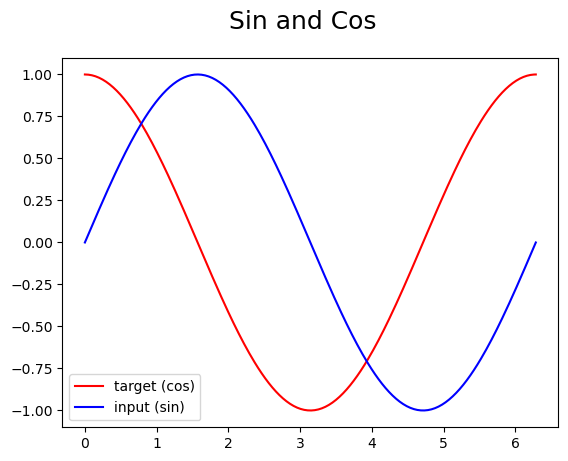

In [4]:
plt.figure(1)
plt.suptitle('Sin and Cos',fontsize='18')
plt.plot(steps, y, 'r-', label='target (cos)')
plt.plot(steps, x, 'b-', label='input (sin)')
plt.legend(loc='best')
plt.show()

In [5]:
class rnn(nn.Module):
    def __init__(self):
        super(rnn,self).__init__()
        self.rnn = nn.RNN(
            input_size = input_size,
            hidden_size = h_size,
            num_layers = 1,
            batch_first = True
        )
        self.out = nn.Linear(h_size,1)
    def forward(self,x,h_state):
        r_out,h_state = self.rnn(x,h_state)
        outs = []
        for time_step in range(r_out.size(1)):
            outs.append(self.out(r_out[:,time_step,:]))
        return torch.stack(outs,dim=1),h_state

In [6]:
rnn = rnn().to(device)
optim = torch.optim.Adam(rnn.parameters())
criterion = nn.MSELoss()

EPOCHS: 19,Loss:0.057253


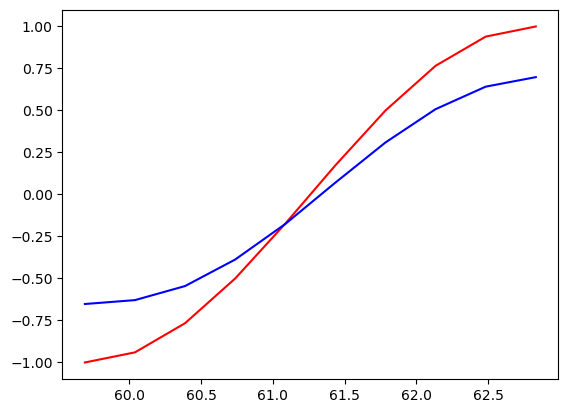

EPOCHS: 39,Loss:0.015365


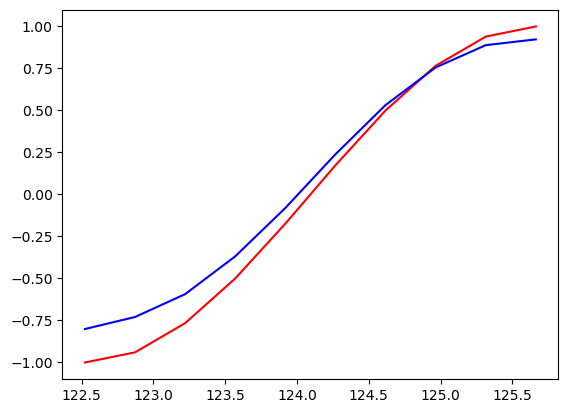

EPOCHS: 59,Loss:0.009172


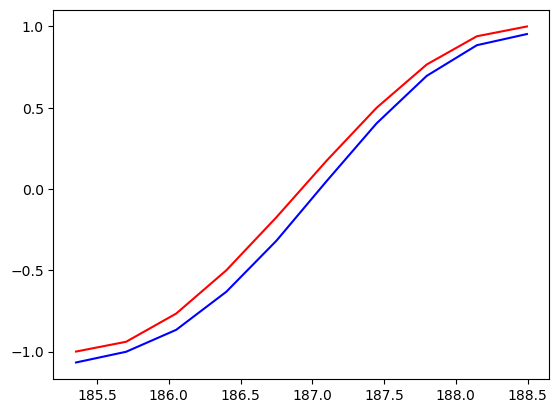

EPOCHS: 79,Loss:0.040718


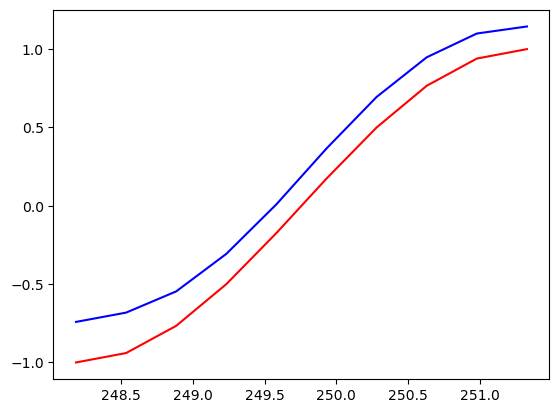

EPOCHS: 99,Loss:0.015911


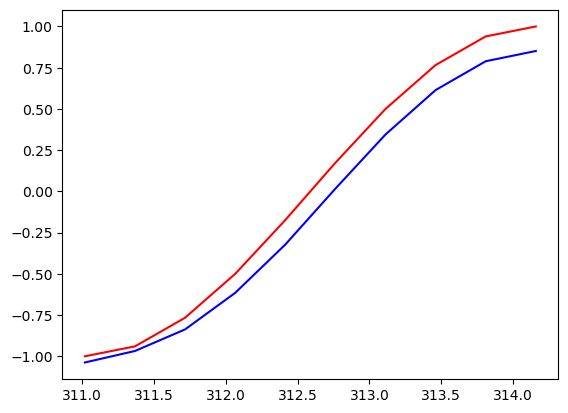

EPOCHS: 119,Loss:0.002421


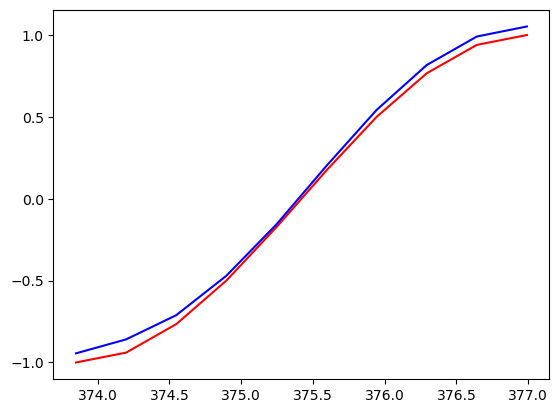

EPOCHS: 139,Loss:0.010551


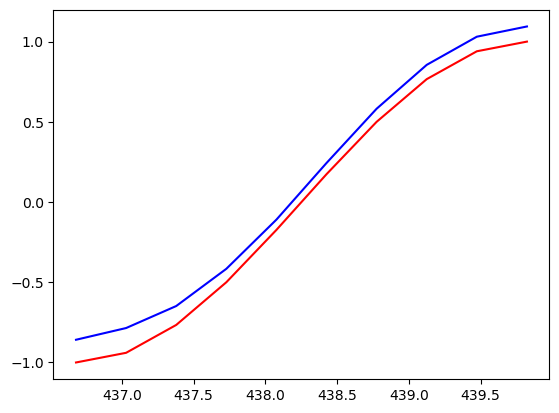

EPOCHS: 159,Loss:0.004218


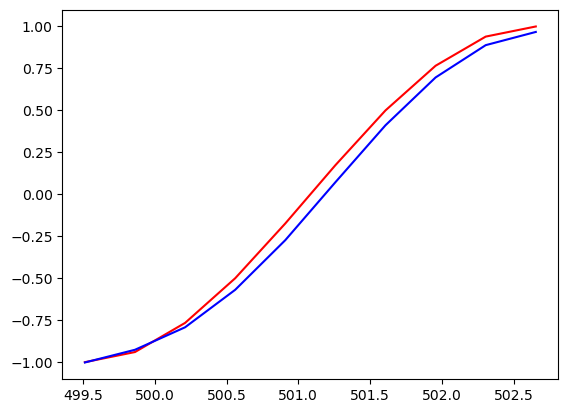

EPOCHS: 179,Loss:0.006188


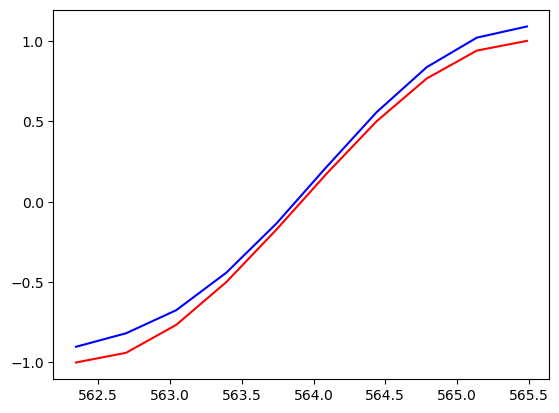

EPOCHS: 199,Loss:0.003185


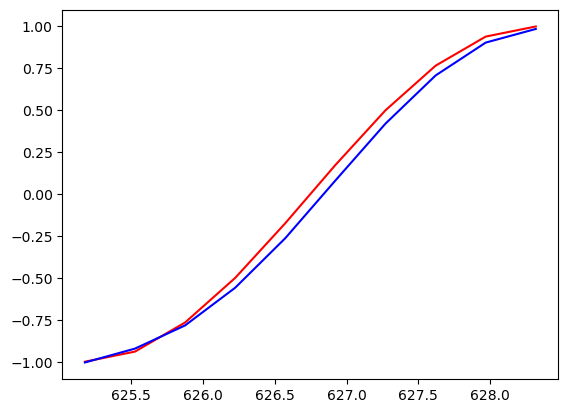

EPOCHS: 219,Loss:0.002120


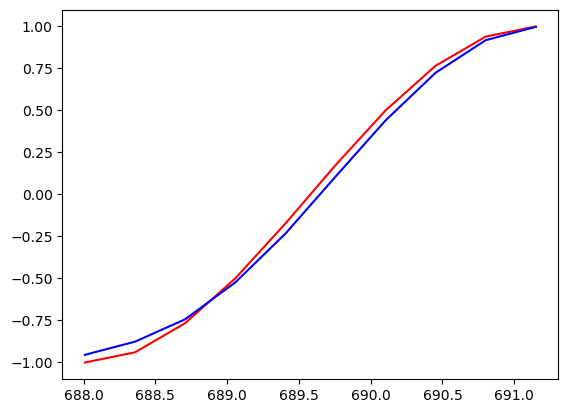

EPOCHS: 239,Loss:0.004100


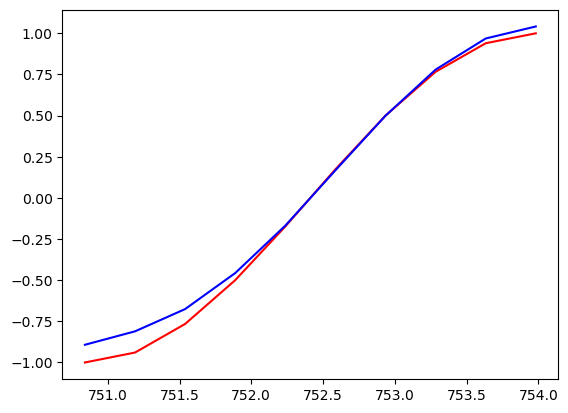

EPOCHS: 259,Loss:0.011658


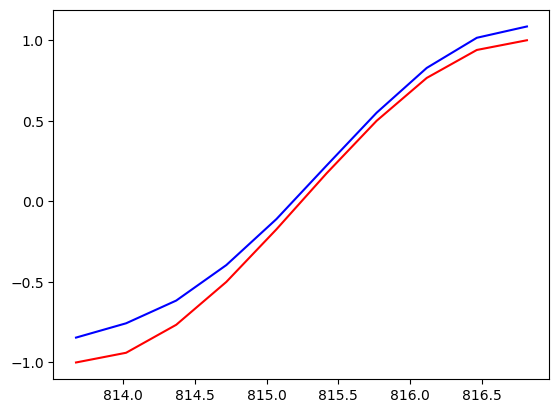

EPOCHS: 279,Loss:0.017962


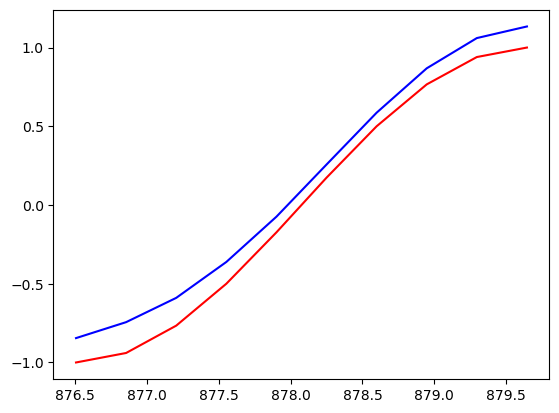

EPOCHS: 299,Loss:0.010422


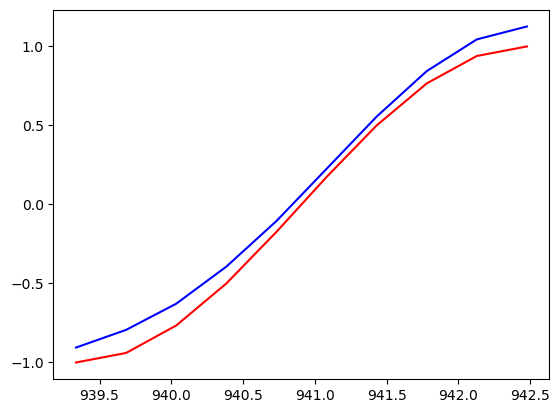

In [7]:
rnn.train()
plt.figure(2)
for step in range(epochs):
    start, end = step * np.pi, (step+1)*np.pi 
    steps = np.linspace(start, end, time_step, dtype=np.float32)
    x_np = np.sin(steps) 
    y_np = np.cos(steps)
    x = torch.from_numpy(x_np[np.newaxis, :, np.newaxis]) # shape (batch, time_step, input_size)
    y = torch.from_numpy(y_np[np.newaxis, :, np.newaxis])
    x=x.to(device)
    prediction, h_state = rnn(x, h_state) # rnn output
    # Very important
    h_state = h_state.data 
    loss = criterion(prediction.cpu(), y) 
    
    optim.zero_grad() 
    loss.backward() 
    optim.step() 
    if (step+1)%20==0: 
        print("EPOCHS: {},Loss:{:4f}".format(step,loss))
        plt.plot(steps, y_np.flatten(), 'r-')
        plt.plot(steps, prediction.cpu().data.numpy().flatten(), 'b-')
        plt.draw()
        plt.pause(0.01)